# Logistic Regression

Logistic Regression is a statistical and machine-learning algorithm used for binary classification that models the probability of an outcome using the logistic (sigmoid) function.

It predicts a value between 0 and 1, which is then mapped to a class label (e.g., 0 or 1).

Logistic regression estimates the probability that a given input belongs to a particular class by modeling the log-odds of the event as a linear combination of input features.

✅ Key Characteristics

Used for binary classification

Outputs probabilities

Decision boundary is linear in feature space

Trained using maximum likelihood estimation

Uses log loss (binary cross-entropy)

### Business Problem:

Insurance companies often face challenges in managing claims efficiently. 

One critical aspect is understanding whether a claimant will hire an attorney to represent 

them in the claim process. This can significantly impact the cost, duration, and outcome of the claim.

### Problem Discussion:

Why is this important?

When claimants hire attorneys, it often leads to higher settlement costs and longer processing times 

for insurance companies. Predicting the likelihood of attorney involvement helps insurers allocate

resources more effectively, streamline claim processing, and potentially reduce unnecessary legal expenses.

### Prediction

The goal is to build a logistic regression model that predicts whether a claimant will hire an attorney (ATTORNEY = 1) or not (ATTORNEY = 0) based on features such as:

Claimant’s demographics (age, gender)

Insurance details (claim insurance status)

Accident-related factors (seatbelt usage, loss amount)


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
import seaborn as sns

In [3]:
df = pd.read_csv('Datasets/5_claimants.csv')
df.head()

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038


<Axes: >

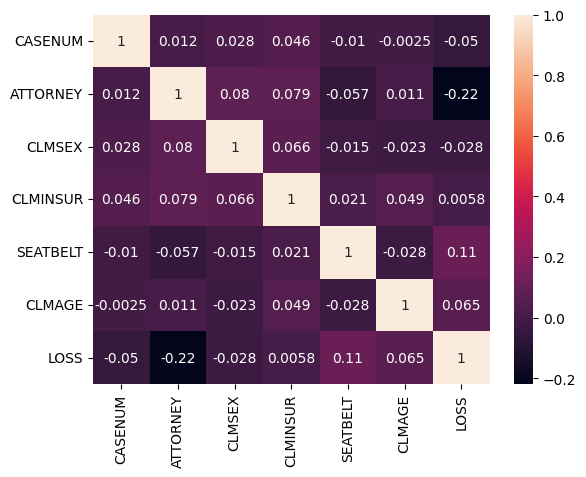

In [4]:
sns.heatmap(df.corr(),annot=True)

so it seems like nothing is corelated to each other.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   CASENUM   1340 non-null   int64  
 1   ATTORNEY  1340 non-null   int64  
 2   CLMSEX    1328 non-null   float64
 3   CLMINSUR  1299 non-null   float64
 4   SEATBELT  1292 non-null   float64
 5   CLMAGE    1151 non-null   float64
 6   LOSS      1340 non-null   float64
dtypes: float64(5), int64(2)
memory usage: 73.4 KB


Now checking for duplicates

In [6]:
len(df['CASENUM'].unique())

1283

therefore 1283 ids are unique.

In [7]:
df.isna().sum()

CASENUM       0
ATTORNEY      0
CLMSEX       12
CLMINSUR     41
SEATBELT     48
CLMAGE      189
LOSS          0
dtype: int64

### Observation - 
- Observations
- ClMAGE has the nmost missing values (189).


Dropping Irreleavant columns

In [8]:
df.drop(["CASENUM"], inplace=True, axis = 1)

In [9]:
df

,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,0,0.0,1.0,0.0,50.0,34.940
1,1,1.0,0.0,0.0,18.0,0.891
2,1,0.0,1.0,0.0,5.0,0.330
3,0,0.0,1.0,1.0,31.0,0.037
4,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...
1335,1,0.0,1.0,0.0,NaN,0.576
1336,0,1.0,1.0,0.0,46.0,3.705
1337,1,1.0,1.0,0.0,39.0,0.099
1338,0,1.0,0.0,0.0,8.0,3.177


In [10]:
#Removing NA values in dataset.

df = df.dropna()
df.shape

(1096, 6)

Before dropping, you must approach your team leader or seniour person and then only drop the na.

In [11]:
pred_var = 'ATTORNEY'
X = df.drop(pred_var, axis = 1
            )
y = df[pred_var]

X

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,0.0,1.0,0.0,50.0,34.940
1,1.0,0.0,0.0,18.0,0.891
2,0.0,1.0,0.0,5.0,0.330
3,0.0,1.0,1.0,31.0,0.037
4,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...
1334,1.0,1.0,0.0,16.0,0.060
1336,1.0,1.0,0.0,46.0,3.705
1337,1.0,1.0,0.0,39.0,0.099
1338,1.0,0.0,0.0,8.0,3.177


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.2, random_state= 42)

In [13]:
X.head()

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,0.0,1.0,0.0,50.0,34.940
1,1.0,0.0,0.0,18.0,0.891
2,0.0,1.0,0.0,5.0,0.330
3,0.0,1.0,1.0,31.0,0.037
4,0.0,1.0,0.0,30.0,0.038


In [14]:
y.head()

0    0
1    1
2    1
3    0
4    1
Name: ATTORNEY, dtype: int64

In [15]:
model = LogisticRegression()
model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [16]:
predicted = model.predict(X_test)

Compare = pd.DataFrame({
    'Original:': y_test, 
    'Predicted:': predicted})

Compare.head()

,Original:,Predicted:
51,1,1
694,0,1
70,0,0
774,1,1
595,0,0


In [17]:
# Accuracy
print(accuracy_score(y_test, predicted))

0.69327251995439


### Observation:

 - If test accuracy (~70%) matches training accuracy (~70%), the model generalizes well.

 - If test accuracy is much lower, the model is overfitting.

In [18]:
model.predict_proba(X)

array([[9.99999657e-01, 3.43430695e-07],
       [4.63366699e-01, 5.36633301e-01],
       [3.56839092e-01, 6.43160908e-01],
       ...,
       [2.77641216e-01, 7.22358784e-01],
       [7.13706819e-01, 2.86293181e-01],
       [3.39823199e-01, 6.60176801e-01]], shape=(1096, 2))

In [19]:
# The array shows predicted probabilities for each class (0 and 1).

# Example: [9.99999653e-01, 3.47e-07] means 99.99% probability of class 0 (no attorney) and 0.0000347% for class 1.

In [20]:
confusion_matrix(y_test, predicted)

array([[287, 174],
       [ 95, 321]])

ROC AUC Curve

In [21]:
y_pred_proba = model.predict_proba(X_test)[:,1]
# Probabilities for class 1

# Calculate ROC score
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculate AUC score
auc_score = roc_auc_score(y_test, y_pred_proba)
print(auc_score)

0.758945332054063


fpr is false positive rate
tpr is true positive rate


In [22]:
fpr

array([0.        , 0.        , 0.        , 0.0021692 , 0.0021692 ,
       0.00433839, 0.00433839, 0.00650759, 0.00650759, 0.01084599,
       0.01084599, 0.01301518, 0.01301518, 0.01518438, 0.01518438,
       0.01735358, 0.01735358, 0.01952278, 0.01952278, 0.02386117,
       0.02386117, 0.02603037, 0.02603037, 0.03036876, 0.03036876,
       0.03470716, 0.03470716, 0.03687636, 0.03687636, 0.03904555,
       0.03904555, 0.04121475, 0.04121475, 0.04338395, 0.04338395,
       0.04772234, 0.04772234, 0.04989154, 0.04989154, 0.05206074,
       0.05206074, 0.05422993, 0.05422993, 0.05639913, 0.05639913,
       0.05856833, 0.05856833, 0.06073753, 0.06073753, 0.06290672,
       0.06290672, 0.06507592, 0.06507592, 0.06724512, 0.06941432,
       0.07158351, 0.07158351, 0.07592191, 0.07592191, 0.07809111,
       0.07809111, 0.0802603 , 0.0824295 , 0.0824295 , 0.0845987 ,
       0.0845987 , 0.0867679 , 0.0867679 , 0.08893709, 0.08893709,
       0.09327549, 0.09327549, 0.09544469, 0.09544469, 0.09761

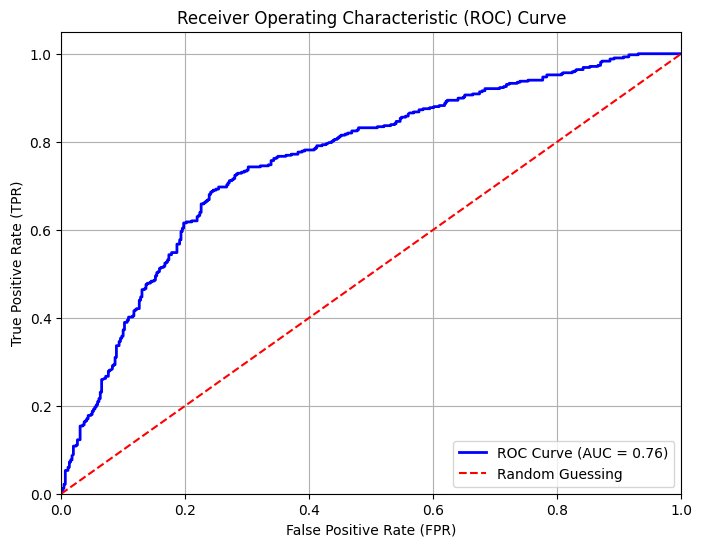

In [23]:
# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, 
         label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guessing')

# Customize plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')

plt.title('Receiver Operating Characteristic (ROC) Curve')

plt.legend(loc="lower right")

plt.grid(True)

# Show plot
plt.show()

In [24]:
y_pred_train = model.predict(X_train)
print("Train Accuracy:", accuracy_score(y_train, y_pred_train))

Train Accuracy: 0.7214611872146118


### Similar accuracy for train and test → Good generalization.

### Train accuracy >> Test accuracy → Overfitting (need regularization or feature selection).


In [25]:
from sklearn.metrics import accuracy_score

# Get predictions for both train and test sets
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Calculate accuracies
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print(f"Train Accuracy: {train_accuracy:.3f}")
print(f"Test Accuracy: {test_accuracy:.3f}")

# Determine generalization status
if abs(train_accuracy - test_accuracy) < 0.05:
    print("✅ Good generalization (similar accuracies)")
elif train_accuracy > test_accuracy + 0.1:
    print("⚠️ Overfitting detected (train >> test). Solutions:")
    print("- Add regularization (e.g., LogisticRegression(penalty='l2', C=0.1))")
    print("- Reduce features (select top features using RFE or feature_importances_)")
    print("- Increase training data or use cross-validation")
else:
    print("❓ Check model or data (unexpected gap)")

Train Accuracy: 0.721
Test Accuracy: 0.693
✅ Good generalization (similar accuracies)


### Key Enhancements

### 1. Regularization (L2 Penalty)

### What?

A technique to prevent overfitting by penalizing overly complex models. L2 regularization (aka "Ridge") shrinks coefficient values toward zero but never fully removes features.

### Why?

When your model performs well on training data but poorly on test data (overfitting), L2 regularization helps by:

Reducing the impact of less important features.

Keeping all features but with smaller weights.

In [26]:
# Improved model with regularization
classifier = LogisticRegression(penalty='l2', C=0.1, solver='liblinear', random_state=42)
classifier.fit(X_train, y_train)

c:\Users\Amey\Desktop\Amey Study\Data Science\TubeDude\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` p

In [27]:
# Why?

# penalty='l2' reduces overfitting by penalizing large coefficients.

# C=0.1 increases regularization strength (lower C = stronger penalty).

### 2 Feature Selection (RFE)

### What?

Recursive Feature Elimination (RFE) selects the top n most important features by recursively removing the least significant ones.

### Why?
Improves generalization by eliminating noisy/irrelevant features.

Reduces training time and model complexity.

In [28]:
from sklearn.feature_selection import RFE

# Select top 3 features
selector = RFE(classifier, n_features_to_select=3, step=1)
selector.fit(X_train, y_train)
print("Selected features:", X_train.columns[selector.support_])

Selected features: Index(['CLMSEX', 'CLMINSUR', 'LOSS'], dtype='object')


c:\Users\Amey\Desktop\Amey Study\Data Science\TubeDude\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Amey\Desktop\Amey Study\Data Science\TubeDude\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Amey\Desktop\Amey Study\Data Science\TubeDude\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 

In [29]:
#Removes irrelevant features that may cause overfitting.

### 3. Cross-Validation

### What?

A method to evaluate model performance by splitting data into multiple train/test folds (e.g., 5-fold).

### Why?

Provides a robust estimate of generalization error.

Reduces reliance on a single train-test split.

In [30]:
from sklearn.model_selection import cross_val_score

# 5-fold cross-validation
cv_scores = cross_val_score(classifier, X_train, y_train, cv=5, scoring='accuracy')
print(f"Cross-validated Accuracy: {cv_scores.mean():.3f} (±{cv_scores.std():.3f})")

Cross-validated Accuracy: 0.722 (±0.038)


c:\Users\Amey\Desktop\Amey Study\Data Science\TubeDude\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Amey\Desktop\Amey Study\Data Science\TubeDude\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Amey\Desktop\Amey Study\Data Science\TubeDude\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 

# 💻📉 Logistic Regression for Customer Churn Prediction

### Design a machine learning algorithm , which will predict an employee will churn or not based on various predictors

In [31]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [32]:
df = pd.read_csv("Datasets/5_churn_data.csv")
df.head()

,customerID,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,1,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,34,Yes,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,2,Yes,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,45,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,2,Yes,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   tenure            7043 non-null   int64  
 2   PhoneService      7043 non-null   object 
 3   Contract          7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
 8   Churn             7043 non-null   object 
dtypes: float64(1), int64(1), object(7)
memory usage: 495.3+ KB


In [34]:
df[['Churn','PhoneService','Contract']].value_counts()

Churn  PhoneService  Contract      
No     Yes           Month-to-month    1997
Yes    Yes           Month-to-month    1502
No     Yes           Two year          1489
                     One year          1176
       No            Month-to-month     223
                     Two year           158
Yes    No            Month-to-month     153
       Yes           One year           152
No     No            One year           131
Yes    Yes           Two year            45
       No            One year            14
                     Two year             3
Name: count, dtype: int64

# allways do analysis for all such variables

In [35]:
df[['Contract']].value_counts()

Contract      
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

### Data Cleaning and Preperation

In [36]:
df.isna().sum()

customerID          0
tenure              0
PhoneService        0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Seems like our data is already clean

In [37]:
df.select_dtypes(include=['object']).columns

Index(['customerID', 'PhoneService', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'TotalCharges', 'Churn'],
      dtype='object')

In [38]:
df.head()

,customerID,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,1,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,34,Yes,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,2,Yes,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,45,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,2,Yes,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Encoding Categorical Values

#### Purpose of the Code
#### The purpose of this code is to encode categorical variables in the churn_data DataFrame into numerical values.

This is often necessary because many machine learning algorithms require numerical input and cannot   handle categorical data directly.

In [39]:
df.dtypes

customerID           object
tenure                int64
PhoneService         object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [40]:
# Encoding categorical variables (non-numeric columns) using Label Encoding
# - `fit_transform()` does two things:
#   1. `fit()`: Learns the unique categories in the column (e.g., "Yes"/"No" → 0/1)
#   2. `transform()`: Converts the text categories into numerical labels
# - We skip 'customerID' since it's just an identifier and not useful for modeling

In [41]:
label_encoders = {}
for column in df.select_dtypes(include=['object']).columns:
    if column != 'customerID':
        label_encoders[column] = LabelEncoder()
        df[column] = label_encoders[column].fit_transform(df[column])

In [42]:
df.dtypes

customerID           object
tenure                int64
PhoneService          int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges          int64
Churn                 int64
dtype: object

In [43]:
df.head()

,customerID,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,1,0,0,1,2,29.85,2505,0
1,5575-GNVDE,34,1,1,0,3,56.95,1466,0
2,3668-QPYBK,2,1,0,1,3,53.85,157,1
3,7795-CFOCW,45,0,1,0,0,42.30,1400,0
4,9237-HQITU,2,1,0,1,2,70.70,925,1


#### Defining Dependent and Independent variables

In [44]:
X = df.drop(['customerID', 'Churn'], axis = 1)
y = df['Churn']
X.head()

,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,1,0,0,1,2,29.85,2505
1,34,1,1,0,3,56.95,1466
2,2,1,0,1,3,53.85,157
3,45,0,1,0,0,42.30,1400
4,2,1,0,1,2,70.70,925


Splitting X and y into Traning and Testing sets

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [46]:
X_test.shape

(1409, 7)

In [47]:
y_test.shape

(1409,)

In [48]:
X_test.head()

,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
185,1,0,0,1,2,24.80,2044
2715,41,1,0,1,0,25.25,6522
3825,52,1,2,0,3,19.35,67
1807,1,1,0,0,2,76.35,5822
132,67,1,2,0,0,50.55,2837


Since all the numericall values are in different scale.

and if higher value (Total Charges) - there is possibility that my logistic regression may give higher importance to it

and we want each feature to have equal importance, so we use Standard Scalar

Standard scaling is applied to ensure all features have zero mean and unit variance, preventing features with larger scales from dominating the model and helping algorithms converge faster and more reliably.

The scaler is fitted only on training data to learn scaling parameters (mean and standard deviation) without exposing the model to test data, thereby avoiding data leakage.

The same transformation is then applied to both training and test data using transform(), ensuring consistency while keeping the test set truly unseen.

In [49]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [50]:
X_train

array([[-4.65683364e-01,  3.29573443e-01,  3.72908354e-01, ...,
         1.33926673e+00, -4.73723375e-04, -1.40800618e+00],
       [ 8.85536787e-01,  3.29573443e-01,  1.57759050e+00, ...,
        -1.47094882e+00,  1.07475386e+00,  5.58360318e-01],
       [-1.28460467e+00, -3.03422506e+00, -8.31773795e-01, ...,
         4.02528212e-01, -1.37649913e+00, -7.02892284e-01],
       ...,
       [-8.34197950e-01,  3.29573443e-01, -8.31773795e-01, ...,
         4.02528212e-01, -1.45294499e+00, -3.21706651e-01],
       [-8.34197950e-01,  3.29573443e-01, -8.31773795e-01, ...,
         4.02528212e-01,  1.14953785e+00, -1.53524478e+00],
       [-2.60953038e-01,  3.29573443e-01,  3.72908354e-01, ...,
        -5.34210304e-01, -1.49781538e+00,  3.30921324e-01]],
      shape=(5634, 7))

### Building out Logistic Regression Model

In [51]:
model = LogisticRegression()
model.fit(X=X_train,y=y_train)
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 1], shape=(1409,))

In [52]:
outcome = pd.DataFrame({
    'original' : y_test,
    'predicted': y_pred
})
outcome.head()

,original,predicted
185,1,0
2715,0,0
3825,0,0
1807,1,1
132,0,0


### Feature Selection using RFE (Recursive Feature Elimination)

- Goal: Automaticcally select the top m most important features to improve model performance.
- How it works: RFE recursively removes the least important features and trains the model.
- Why use it?: Reduces overfitting, speeds up training, and simplifies interpretation.
- It is a feature selection technique that recursiverly removes the least important features and builds a model using remaining attributes.

In [53]:
from sklearn.feature_selection import RFE

rfe_model = LogisticRegression()
rfe = RFE(estimator=rfe_model, n_features_to_select=5)

# Why 5 features? Rule of thumb: Start with sqrt(total_features) or use cross-validation.
# Here, we pick 5 for demonstation-adjust based on model performance

In [54]:
# Fit RFE
rfe.fit(X_train, y_train)

# Get the selected features
selected_features = rfe.support_

# Transform the datasets
X_train_rfe = rfe.transform(X_train)
X_test_rfe = rfe.transform(X_test)

# Retrain the model on the selected features
model.fit(X_train_rfe, y_train)

# Make predictions
y_pred_rfe = model.predict(X_test_rfe)


### Model Evaluation

In [55]:
from sklearn.metrics import confusion_matrix, accuracy_score

# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_rfe)

print("Confusion Matrix:\n", conf_matrix)



Confusion Matrix:
 [[937  99]
 [170 203]]


In [56]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_rfe)
print("Accuracy: ", accuracy)


Accuracy:  0.8090844570617459


In [57]:
from sklearn.metrics import confusion_matrix, accuracy_score

# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)


Confusion Matrix:
 [[938  98]
 [175 198]]
Accuracy:  0.8062455642299503
